<a href="https://colab.research.google.com/github/Chinmaya1909/C-and-C-assignments/blob/master/capstone_notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q streamlit joblib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 50.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 72.6 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.datasets import load_breast_cancer

data = load_breast_cancer(as_frame=True)

df = data.frame.copy()
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [3]:
print(df.shape)
print(df.columns.tolist())

(569, 31)
['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness', 'mean compactness', 'mean concavity', 'mean concave points', 'mean symmetry', 'mean fractal dimension', 'radius error', 'texture error', 'perimeter error', 'area error', 'smoothness error', 'compactness error', 'concavity error', 'concave points error', 'symmetry error', 'fractal dimension error', 'worst radius', 'worst texture', 'worst perimeter', 'worst area', 'worst smoothness', 'worst compactness', 'worst concavity', 'worst concave points', 'worst symmetry', 'worst fractal dimension', 'target']


In [5]:
print("Dataset shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

print("\nSummary statistics:")
display(df.describe())

print("\nMissing values:")
print(df.isnull().sum().sum())

print("\nTarget distribution:")
print(df["target"].value_counts())

print("\nTarget names:")
print(data.target_names)

Dataset shape: (569, 31)

Column names:
['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness', 'mean compactness', 'mean concavity', 'mean concave points', 'mean symmetry', 'mean fractal dimension', 'radius error', 'texture error', 'perimeter error', 'area error', 'smoothness error', 'compactness error', 'concavity error', 'concave points error', 'symmetry error', 'fractal dimension error', 'worst radius', 'worst texture', 'worst perimeter', 'worst area', 'worst smoothness', 'worst compactness', 'worst concavity', 'worst concave points', 'worst symmetry', 'worst fractal dimension', 'target']

Summary statistics:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000



Missing values:
0

Target distribution:
target
1    357
0    212
Name: count, dtype: int64

Target names:
['malignant' 'benign']


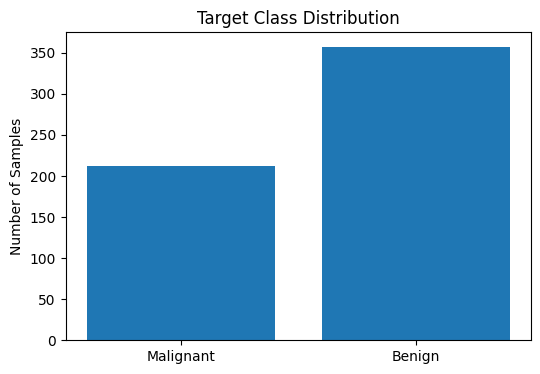

In [6]:
target_counts = df["target"].value_counts().sort_index()

plt.figure(figsize=(6, 4))
plt.bar(["Malignant", "Benign"], target_counts.values)
plt.title("Target Class Distribution")
plt.ylabel("Number of Samples")
plt.show()

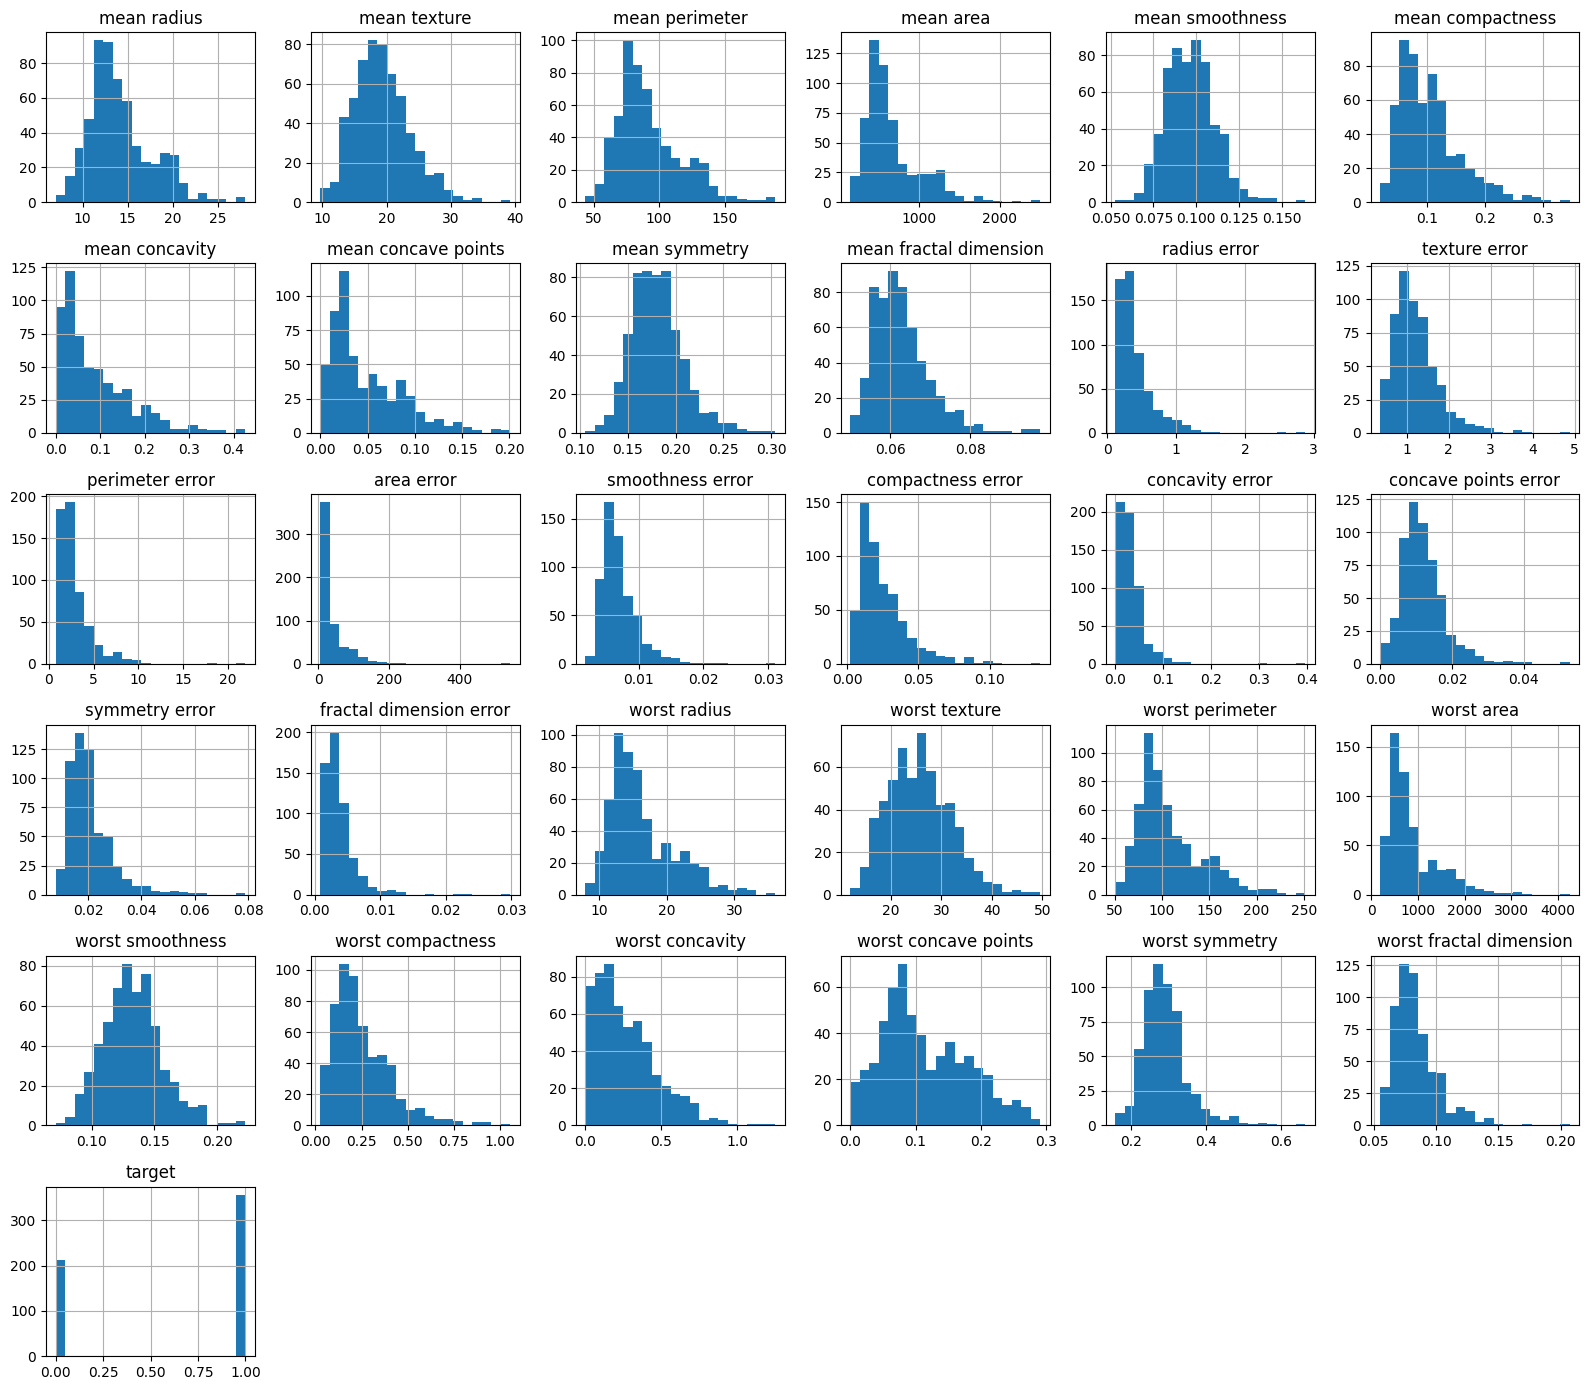

In [7]:
df.hist(figsize=(16, 14), bins=20)
plt.tight_layout()
plt.show()

In [8]:
X = df.drop(columns=["target"])
y = df["target"]

print("Features:", X.shape)
print("Target:", y.shape)

Features: (569, 30)
Target: (569,)


In [9]:
print(X.isnull().sum().sum())
print(y.isnull().sum())

0
0


In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(455, 30)
(114, 30)


In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

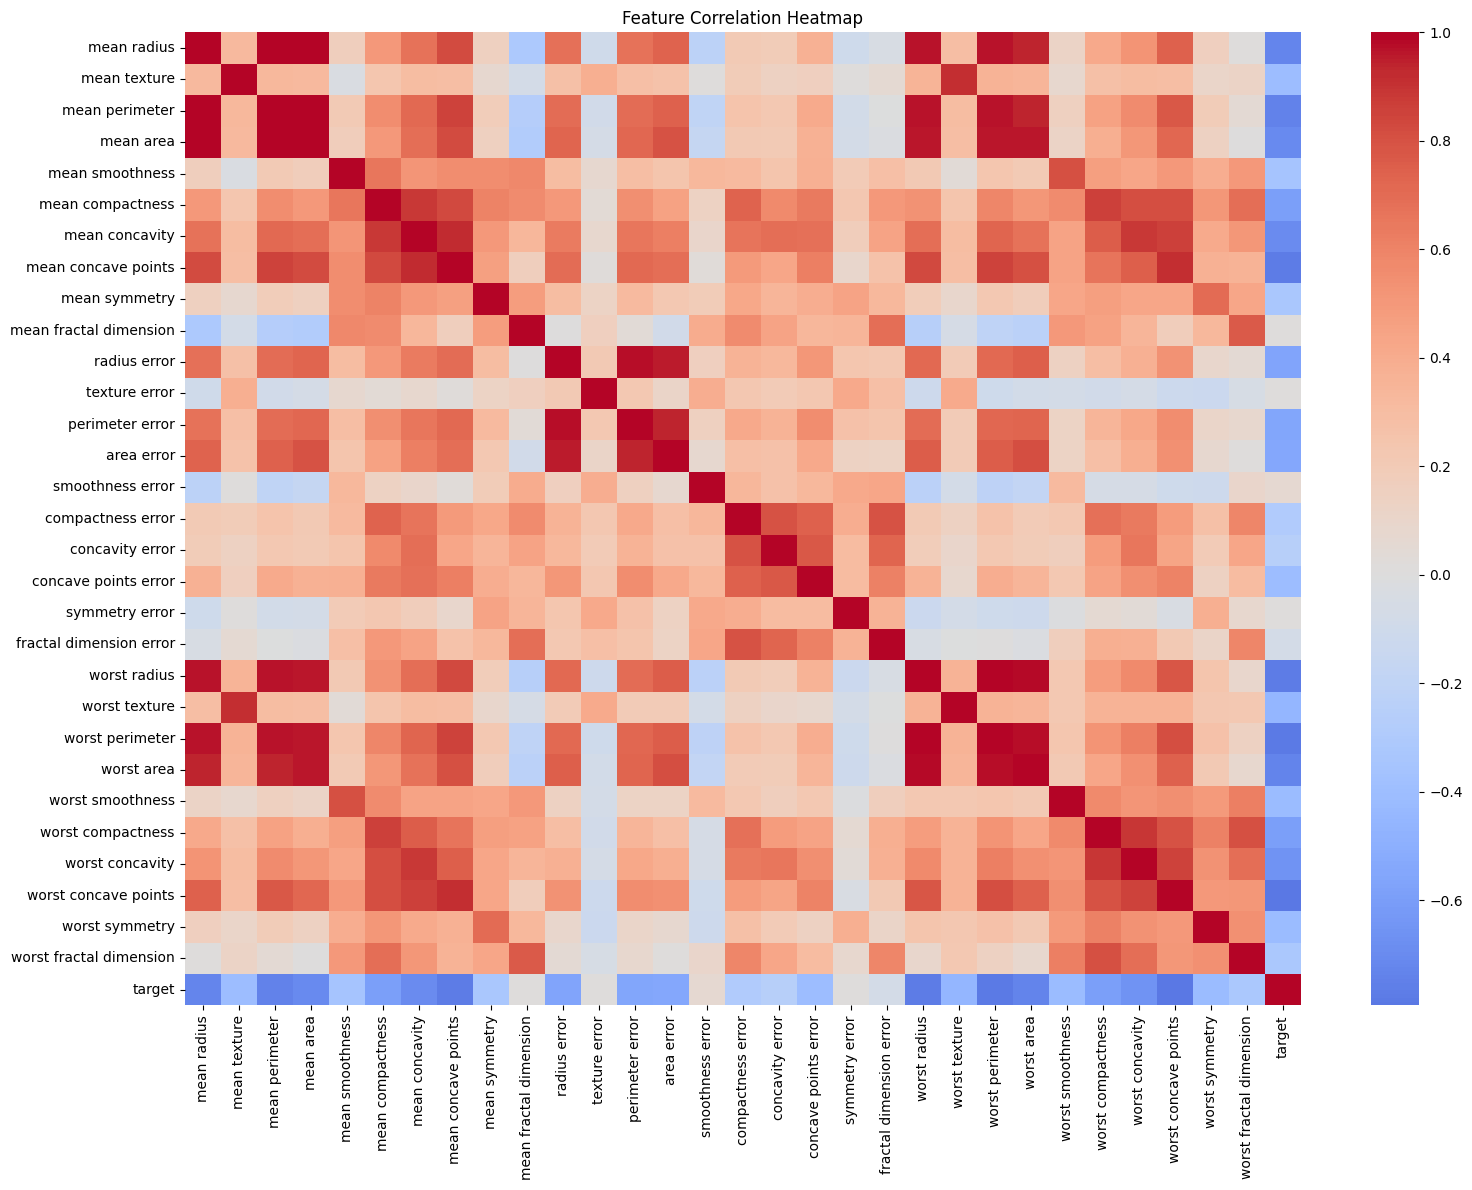

In [12]:
plt.figure(figsize=(16, 12))

sns.heatmap(
    df.corr(),
    cmap="coolwarm",
    center=0,
    xticklabels=True,
    yticklabels=True
)

plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

In [13]:
target_correlations = (
    df.corr()["target"]
    .drop("target")
    .abs()
    .sort_values(ascending=False)
)

display(target_correlations.head(10))

,target
worst concave points,0.793566
worst perimeter,0.782914
mean concave points,0.776614
worst radius,0.776454
mean perimeter,0.742636
worst area,0.733825
mean radius,0.730029
mean area,0.708984
mean concavity,0.696360
worst concavity,0.659610


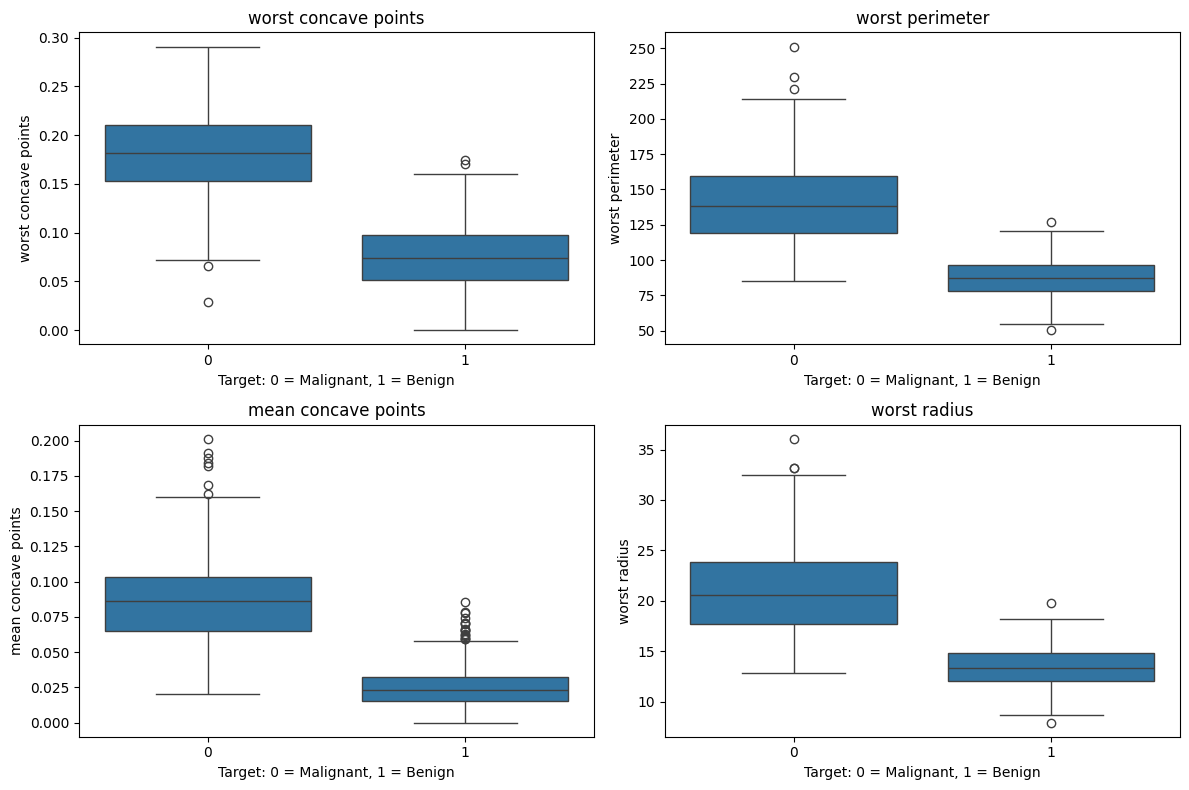

In [14]:
top_features = target_correlations.head(4).index

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()

for ax, feature in zip(axes, top_features):
    sns.boxplot(
        data=df,
        x="target",
        y=feature,
        ax=ax
    )
    ax.set_title(feature)
    ax.set_xlabel("Target: 0 = Malignant, 1 = Benign")

plt.tight_layout()
plt.show()

In [15]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(
    max_iter=5000,
    random_state=42
)

logistic_model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=5000, random_state=42)

In [16]:
from sklearn.ensemble import RandomForestClassifier

forest_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced"
)

forest_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=300,
                       random_state=42)

In [17]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

def evaluate_model(model, X_eval, y_eval, model_name):
    predictions = model.predict(X_eval)
    probabilities = model.predict_proba(X_eval)[:, 1]

    print(f"\n{model_name}")
    print("-" * 40)
    print("Accuracy:", round(accuracy_score(y_eval, predictions), 4))
    print("Precision:", round(precision_score(y_eval, predictions), 4))
    print("Recall:", round(recall_score(y_eval, predictions), 4))
    print("F1-score:", round(f1_score(y_eval, predictions), 4))
    print("ROC-AUC:", round(roc_auc_score(y_eval, probabilities), 4))
    print("\nClassification report:")
    print(classification_report(
        y_eval,
        predictions,
        target_names=["Malignant", "Benign"]
    ))

    return predictions

logistic_predictions = evaluate_model(
    logistic_model,
    X_test_scaled,
    y_test,
    "Logistic Regression"
)

forest_predictions = evaluate_model(
    forest_model,
    X_test,
    y_test,
    "Random Forest"
)


Logistic Regression
----------------------------------------
Accuracy: 0.9825
Precision: 0.9861
Recall: 0.9861
F1-score: 0.9861
ROC-AUC: 0.9954

Classification report:
              precision    recall  f1-score   support

   Malignant       0.98      0.98      0.98        42
      Benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114


Random Forest
----------------------------------------
Accuracy: 0.9474
Precision: 0.9583
Recall: 0.9583
F1-score: 0.9583
ROC-AUC: 0.9937

Classification report:
              precision    recall  f1-score   support

   Malignant       0.93      0.93      0.93        42
      Benign       0.96      0.96      0.96        72

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



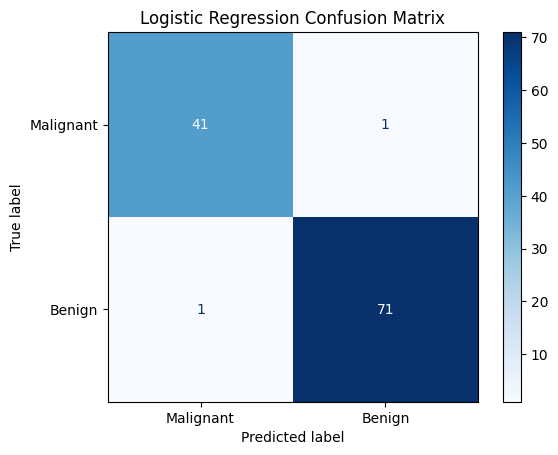

In [18]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    logistic_predictions,
    display_labels=["Malignant", "Benign"],
    cmap="Blues"
)

plt.title("Logistic Regression Confusion Matrix")
plt.show()

In [19]:
joblib.dump(logistic_model, "model.joblib")
joblib.dump(scaler, "scaler.joblib")

['scaler.joblib']

In [20]:
import os

print(os.path.exists("model.joblib"))
print(os.path.exists("scaler.joblib"))

True
True


In [21]:
from google.colab import files

files.download("model.joblib")
files.download("scaler.joblib")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [22]:
from sklearn.pipeline import Pipeline

final_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=5000,
        random_state=42
    ))
])

final_pipeline.fit(X_train, y_train)

joblib.dump(final_pipeline, "model_pipeline.joblib")

['model_pipeline.joblib']

In [23]:
from google.colab import files

files.download("model.joblib")
files.download("scaler.joblib")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [24]:
import streamlit as st
import pandas as pd
import numpy as np
import joblib

st.set_page_config(
    page_title="Breast Cancer Predictor",
    page_icon="🧬",
    layout="wide"
)

st.title("Breast Cancer Diagnosis Predictor")
st.write(
    "Educational machine-learning demonstration using the "
    "scikit-learn Breast Cancer Wisconsin dataset."
)

st.warning(
    "This application is for educational purposes only. "
    "It is not a medical diagnostic tool and must not replace "
    "professional medical advice."
)

model = joblib.load("model.joblib")
scaler = joblib.load("scaler.joblib")

feature_names = [
    "mean radius",
    "mean texture",
    "mean perimeter",
    "mean area",
    "mean smoothness",
    "mean compactness",
    "mean concavity",
    "mean concave points",
    "mean symmetry",
    "mean fractal dimension",
    "radius error",
    "texture error",
    "perimeter error",
    "area error",
    "smoothness error",
    "compactness error",
    "concavity error",
    "concave points error",
    "symmetry error",
    "fractal dimension error",
    "worst radius",
    "worst texture",
    "worst perimeter",
    "worst area",
    "worst smoothness",
    "worst compactness",
    "worst concavity",
    "worst concave points",
    "worst symmetry",
    "worst fractal dimension"
]

st.subheader("Enter tumor measurements")

input_values = {}

columns = st.columns(3)

for i, feature in enumerate(feature_names):
    with columns[i % 3]:
        input_values[feature] = st.number_input(
            feature,
            value=0.0,
            format="%.6f"
        )

if st.button("Predict", type="primary"):
    input_df = pd.DataFrame(
        [input_values],
        columns=feature_names
    )

    scaled_input = scaler.transform(input_df)

    prediction = model.predict(scaled_input)[0]
    probabilities = model.predict_proba(scaled_input)[0]

    if prediction == 0:
        result = "Malignant"
        st.error(f"Prediction: {result}")
    else:
        result = "Benign"
        st.success(f"Prediction: {result}")

    st.write("Model probability estimates:")

    probability_df = pd.DataFrame({
        "Class": ["Malignant", "Benign"],
        "Probability": probabilities
    })

    st.dataframe(
        probability_df.style.format(
            {"Probability": "{:.2%}"}
        ),
        use_container_width=True
    )

2026-10-05 05:48:31.816 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-10-05 05:48:31.820 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-10-05 05:48:32.278 
  command:

    streamlit run /usr/local/lib/python3.13/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-10-05 05:48:32.280 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-10-05 05:48:32.289 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-10-05 05:48:32.299 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-10-05 05:48:32.301 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when runn

In [25]:
feature_ranges = X.describe().T
display(feature_ranges[["min", "max", "mean"]])

,min,max,mean
mean radius,6.981000,28.11000,14.127292
mean texture,9.710000,39.28000,19.289649
mean perimeter,43.790000,188.50000,91.969033
mean area,143.500000,2501.00000,654.889104
mean smoothness,0.052630,0.16340,0.096360
mean compactness,0.019380,0.34540,0.104341
mean concavity,0.000000,0.42680,0.088799
mean concave points,0.000000,0.20120,0.048919
mean symmetry,0.106000,0.30400,0.181162
mean fractal dimension,0.049960,0.09744,0.062798
